In [71]:
#LECTURE DU DATASET
import pandas as pd
data = pd.read_csv('data.csv', encoding='ISO-8859-1')
print("Taille du dataset:", data.shape)
print("Colonnes:", data.columns.tolist())

Taille du dataset: (541909, 8)
Colonnes: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [72]:
#NETTOYAGE DES DONNEES
#1 - Trouver les valeurs manquantes
print(data.isnull().sum())



InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [73]:
#2 - Supprimer les lignes sans customer ID
print("Avant nettoyage:", data.shape)
data = data.dropna(subset = ["CustomerID"])
print("Après nettoyage:", data.shape)

Avant nettoyage: (541909, 8)
Après nettoyage: (406829, 8)


In [74]:
#3 - Supprimer les quantités négatives
print("Lignes quantités négatives:", len(data[data["Quantity"]<0]))
data = data[data["Quantity"]>0]
print("Après suppression des retours:", data.shape)

Lignes quantités négatives: 8905
Après suppression des retours: (397924, 8)


In [75]:
#4 - Créer la colonne revenues
data["Revenues"] = data["Quantity"]*data["UnitPrice"]
print(data[["Quantity", "UnitPrice", "Revenues"]].head(10))

   Quantity  UnitPrice  Revenues
0         6       2.55     15.30
1         6       3.39     20.34
2         8       2.75     22.00
3         6       3.39     20.34
4         6       3.39     20.34
5         2       7.65     15.30
6         6       4.25     25.50
7         6       1.85     11.10
8         6       1.85     11.10
9        32       1.69     54.08


In [76]:
#5 - Vérification du nettoyage
from IPython.display import display
display(data[["UnitPrice", "Revenues", "Quantity"]].head(10))
print("Dataset final:", data.shape)

,UnitPrice,Revenues,Quantity
0,2.55,15.30,6
1,3.39,20.34,6
2,2.75,22.00,8
3,3.39,20.34,6
4,3.39,20.34,6
5,7.65,15.30,2
6,4.25,25.50,6
7,1.85,11.10,6
8,1.85,11.10,6
9,1.69,54.08,32


Dataset final: (397924, 9)


CA par mois
1: 569,445 £
2: 447,137 £
3: 595,501 £
4: 469,200 £
5: 678,595 £
6: 661,214 £
7: 600,091 £
8: 645,344 £
9: 952,838 £
10: 1,039,319 £
11: 1,161,817 £
12: 1,090,907 £


<function matplotlib.pyplot.show(close=None, block=None)>

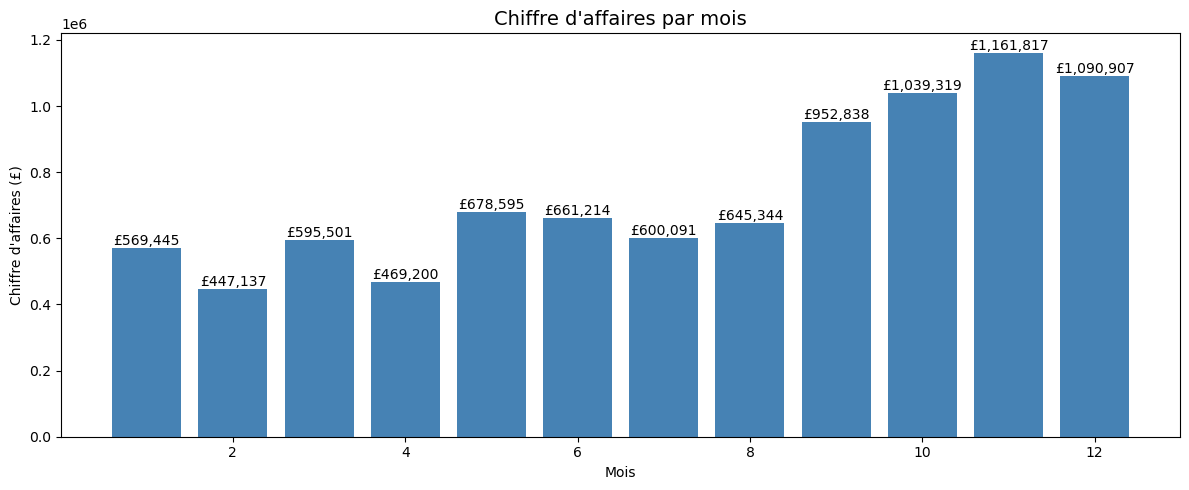

In [77]:
#ANALYSE DES VENTES
import matplotlib.pyplot as plt

#1 - Conversion des dates
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

#2 - Extraction de l'année, du mois et du jour
data["Month"] = data["InvoiceDate"].dt.month
data["Year"] = data["InvoiceDate"].dt.year
data["DayOfWeek"] = data["InvoiceDate"].dt.day_name()

#3 - Calcul du CA par mois
ca_par_mois = data.groupby("Month")["Revenues"].sum()
print("CA par mois")
for mois, valeur in ca_par_mois.items():
    print(f"{mois}: {valeur:,.0f} £")

#4 - Graphique
plt.figure(figsize=(12,5))
plt.bar(ca_par_mois.index, ca_par_mois.values, color = "steelblue")
plt.title("Chiffre d'affaires par mois", fontsize = 14)
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (£)")
for mois, valeurs in zip(ca_par_mois.index, ca_par_mois.values):
    plt.text(mois, valeurs, f"£{valeurs:,.0f}", ha = "center", va = "bottom")
plt.tight_layout()
plt.show


Top 10 Pays par CA:
Sweden: 38,378 £
Belgium: 41,196 £
Switzerland: 56,444 £
Spain: 61,577 £
Australia: 138,521 £
France: 209,024 £
Germany: 228,867 £
EIRE: 265,546 £
Netherlands: 285,446 £
United Kingdom: 7,308,392 £


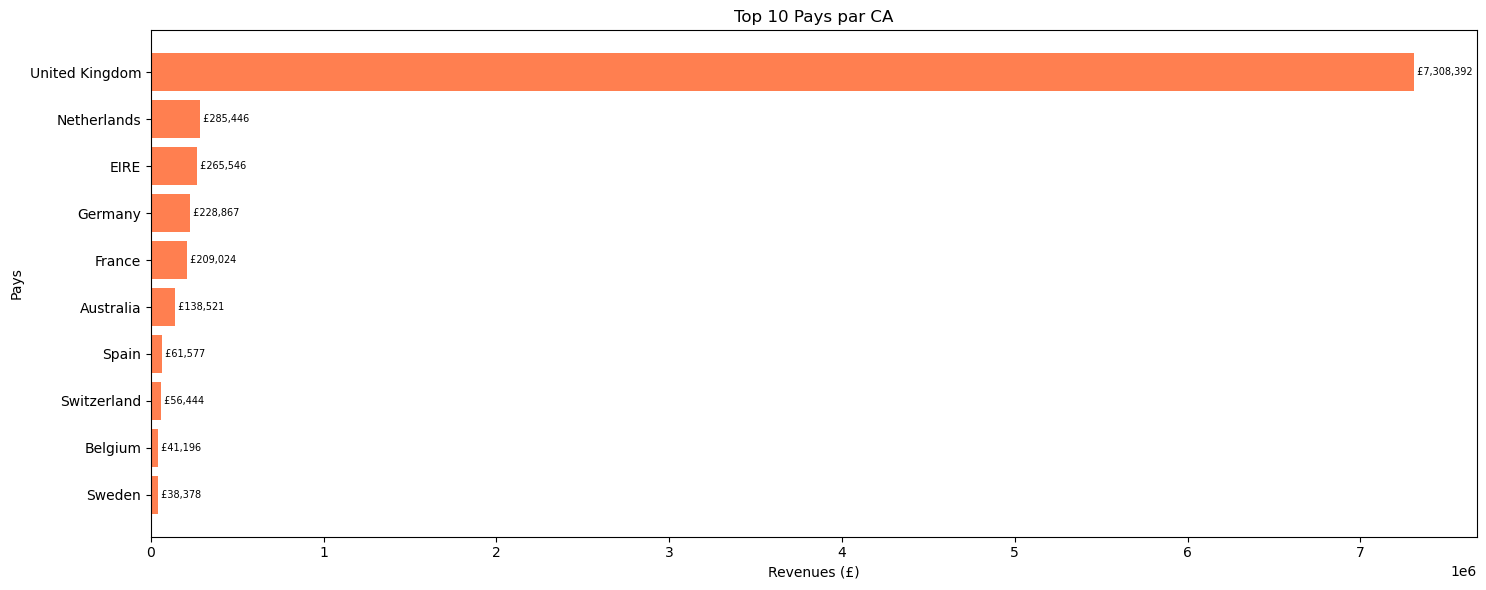

In [78]:
#ANALYSE CA PAR PAYS
#1 - Calcul du CA par Pays
ca_par_pays = data.groupby("Country")["Revenues"].sum()
#2 - Top 10
top_pays = ca_par_pays.sort_values(ascending=True).tail(10)
print("Top 10 Pays par CA:")
for pays, valeur in top_pays.items():
    print(f"{pays}: {valeur:,.0f} £")
#3 - Graphique de présentation du top 10
plt.figure(figsize=(15,6))
plt.barh(top_pays.index, top_pays.values, color = "coral")
plt.title("Top 10 Pays par CA")
plt.xlabel("Revenues (£)")
plt.ylabel("Pays")
for pays, valeurs in zip(top_pays.index, top_pays.values):
    plt.text(valeurs, pays, f' £{valeurs:,.0f}', ha = "left", va = "center", fontsize = 7)
plt.tight_layout()
plt.show()


In [79]:
#CONCLUSION ET PRESENTATION DES INSIGHTS
print("="*50)
print("Insight clés du dataset")
print("="*50)

#CA total
ca_total = data["Revenues"].sum()
print(f"1- CA total: {ca_total:,.0f} £.")

#Nombre de clients uniques
#.nunique() compte le nombre de valeurs uniques dans une colonne
nb_clients_uniques = data["CustomerID"].nunique()
print(f"\n2- Nombre de clients uniques: {nb_clients_uniques:,}.")

#Nombre de produits différents
nb_produits_diff = data["Description"].nunique()
print(f"\n3- Nombre de produits différents: {nb_produits_diff:,}.")

#Meilleur mois
meilleur_mois = ca_par_mois.idxmax()
ca_meilleur_mois = ca_par_mois.max()
print(f"\n4- Meilleur mois: Mois n°{meilleur_mois}")
print(f"CA meilleur mois: {ca_meilleur_mois:,.0f} £.")

#Pire mois
pire_mois = ca_par_mois.idxmin()
ca_pire_mois = ca_par_mois.min()
print(f"\n5- Pire mois: Mois n°{pire_mois}")
print(f"CA pire mois: {ca_pire_mois:,.0f} £.")

#Top pays (hors UK)
pays_hors_uk = ca_par_pays.drop("United Kingdom")
top_pays_hors_uk = pays_hors_uk.idxmax()
ca_top_pays_hors_uk = pays_hors_uk.max()
print(f'\n6- Top pays hors UK: {top_pays_hors_uk}')
print(f"CA top pays hors UK: {ca_top_pays_hors_uk:,.0f} £.")

#Meilleur jour
ca_par_jour = data.groupby("DayOfWeek")["Revenues"].sum()
meilleur_jour = ca_par_jour.idxmax()
print(f"\n7- Meilleur jour de la semaine: {meilleur_jour}.")

#Meilleure date
data["Date"] = data["InvoiceDate"].dt.date
ca_par_date = data.groupby("Date")["Revenues"].sum()
meilleure_date = ca_par_date.idxmax()
ca_meilleure_date = ca_par_date.max()
print(f"\n8- Meilleur jour jour de l'année {meilleure_date}")
print(f"CA meilleur jour jour de l'année{ca_meilleure_date:,.0f} £.")

#Pire date
pire_date = ca_par_date.idxmin()
ca_pire_date = ca_par_date.min()
print(f"\n- Pire jour jour de l'année {pire_date}")
print(f"CA pire jour jour de l'année {ca_pire_date:,.0f} £.")

#Commande moyenne
commande_moyenne = data.groupby("InvoiceNo")["Revenues"].sum().mean()
print(f"\n10- Valeur commande moyenne: {commande_moyenne:,.2f} £.")

#Article le plus commandé
quantité_par_articles = data.groupby("Description")["Quantity"].sum()
article_le_plus_vendu = quantité_par_articles.idxmax()
quantité_article_le_plus_vendu = quantité_par_articles.max()
print(f"\n11- Article le plus vendu: {article_le_plus_vendu} avec {quantité_article_le_plus_vendu:,.0f} unités.")

#Article ayant le plus rapporté
ca_par_articles = data.groupby("Description")["Revenues"].sum()
ca_meilleur_article = ca_par_articles.max()
meilleur_article = ca_par_articles.idxmax()
print(f"\n12- Article ayant rapporté le plus rapporté: {meilleur_article} avec un CA de {ca_meilleur_article:,.0f} £.")

#Article le moins vendu
quantité_minimum = quantité_par_articles.min()
articles_moins_vendus = quantité_par_articles[quantité_par_articles == quantité_minimum]
print(f"\n13- Quantité minimum articles moins vendus: {quantité_minimum}.")
print(f"Nombres d'articles concernés: {len(articles_moins_vendus)}.")
print("Liste des articles:")
print(articles_moins_vendus)

#Article ayant le moins rapporté
data_propre = data[data["UnitPrice"]>0.01]
ca_par_articles_propre = data_propre.groupby("Description")["Revenues"].sum()
pire_article = ca_par_articles_propre.idxmin()
ca_pire_article = ca_par_articles_propre.min()
print(f"\n14- Article ayant rapporté le moins rapporté: {pire_article} avec un CA de {ca_pire_article:,.2f} £.")

#Panier moyen par pays
ca_commande_pays = data.groupby(["InvoiceNo", "Country"])["Revenues"].sum().reset_index()
panier_moyen_pays = ca_commande_pays.groupby("Country")["Revenues"].mean()
max_panier_moyen_pays = panier_moyen_pays.idxmax()
ca_max_panier_moyen_pays = panier_moyen_pays.max()
min_panier_moyen_pays = panier_moyen_pays.idxmin()
ca_min_panier_moyen_pays = panier_moyen_pays.min()
top_10_panier_moyen_pays = panier_moyen_pays.sort_values(ascending=True).tail(10)
print(f"\n15- Le pays ayant le plus gros panier moyen est {max_panier_moyen_pays} avec un panier moyen de {ca_max_panier_moyen_pays:,.0f} £.")
print(f"\n16- Le pays ayant le plus petit panier moyen est {min_panier_moyen_pays} avec un panier moyen de {ca_min_panier_moyen_pays:,.0f} £.")
print("\nTop 10 panier moyen par pays:")
for pays, valeurs in top_10_panier_moyen_pays.items():
    print(f"{pays}: {valeurs:,.0f} £.")

#Nombres d'articles en moyenne
quantité_moyenne = data.groupby("InvoiceNo")["Quantity"].sum().mean()
print(f"\n17- La quantité moyenne d'articles commandés pour une commande est de {quantité_moyenne:,.0f} articles.")

print("="*50)

Insight clés du dataset
1- CA total: 8,911,408 £.

2- Nombre de clients uniques: 4,339.

3- Nombre de produits différents: 3,877.

4- Meilleur mois: Mois n°11
CA meilleur mois: 1,161,817 £.

5- Pire mois: Mois n°2
CA pire mois: 447,137 £.

6- Top pays hors UK: Netherlands
CA top pays hors UK: 285,446 £.

7- Meilleur jour de la semaine: Thursday.

8- Meilleur jour jour de l'année 2011-12-09
CA meilleur jour jour de l'année184,349 £.

- Pire jour jour de l'année 2011-02-06
CA pire jour jour de l'année 3,457 £.

10- Valeur commande moyenne: 480.76 £.

11- Article le plus vendu: PAPER CRAFT , LITTLE BIRDIE avec 80,995 unités.

12- Article ayant rapporté le plus rapporté: PAPER CRAFT , LITTLE BIRDIE avec un CA de 168,470 £.

13- Quantité minimum articles moins vendus: 1.
Nombres d'articles concernés: 59.
Liste des articles:
Description
 I LOVE LONDON MINI RUCKSACK           1
AMBER BERTIE GLASS BEAD BAG CHARM      1
AMBER GLASS/SHELL/PEARL NECKLACE       1
BAROQUE BUTTERFLY EARRINGS CRYSTAL

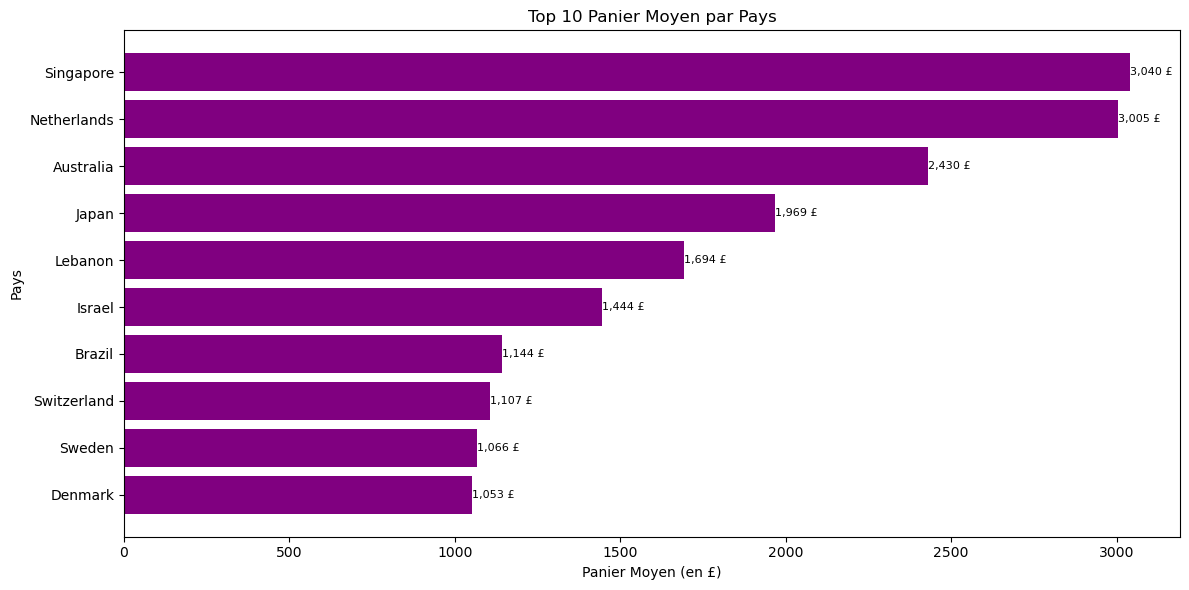

In [80]:
#Graphique panier moyen par pays
plt.figure(figsize=(12,6))
plt.barh(top_10_panier_moyen_pays.index, top_10_panier_moyen_pays.values, color = "purple")
plt.title("Top 10 Panier Moyen par Pays")
plt.xlabel("Panier Moyen (en £)")
plt.ylabel("Pays")
for pays, valeur in zip(top_10_panier_moyen_pays.index, top_10_panier_moyen_pays.values):
    plt.text(valeur, pays, f"{valeur:,.0f} £", ha = "left", va = "center", fontsize = 8)
plt.tight_layout()
plt.show()

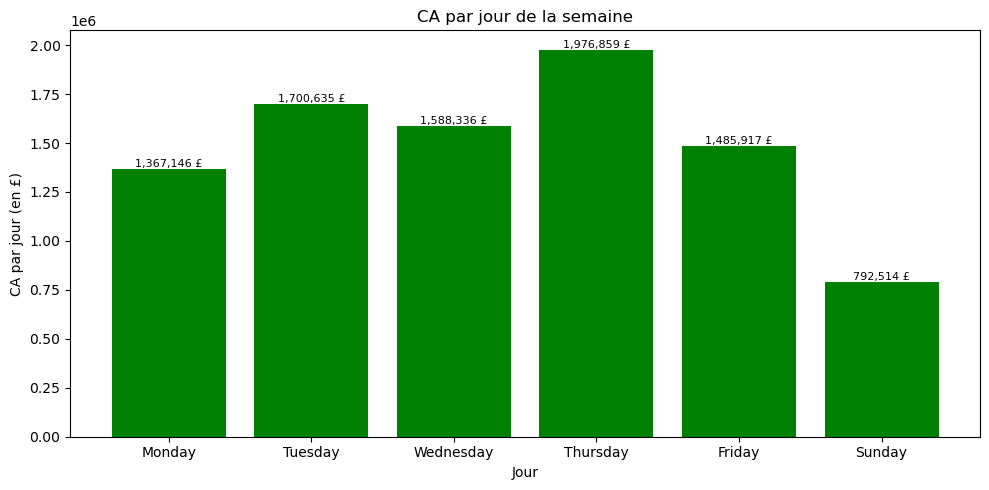

In [81]:
#Graphique CA par jour de la semaine
ordre_jours = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"]
ca_par_jour_ordonné = ca_par_jour.reindex(ordre_jours)
plt.figure(figsize=(10, 5))
plt.bar(ca_par_jour_ordonné.index, ca_par_jour_ordonné.values, color = "green")
plt.title("CA par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("CA par jour (en £)")
for jour, valeur in zip(ca_par_jour_ordonné.index, ca_par_jour_ordonné.values):
    plt.text(jour, valeur, f"{valeur:,.0f} £", ha = "center", va = "bottom", fontsize = 8)
plt.tight_layout()
plt.show()

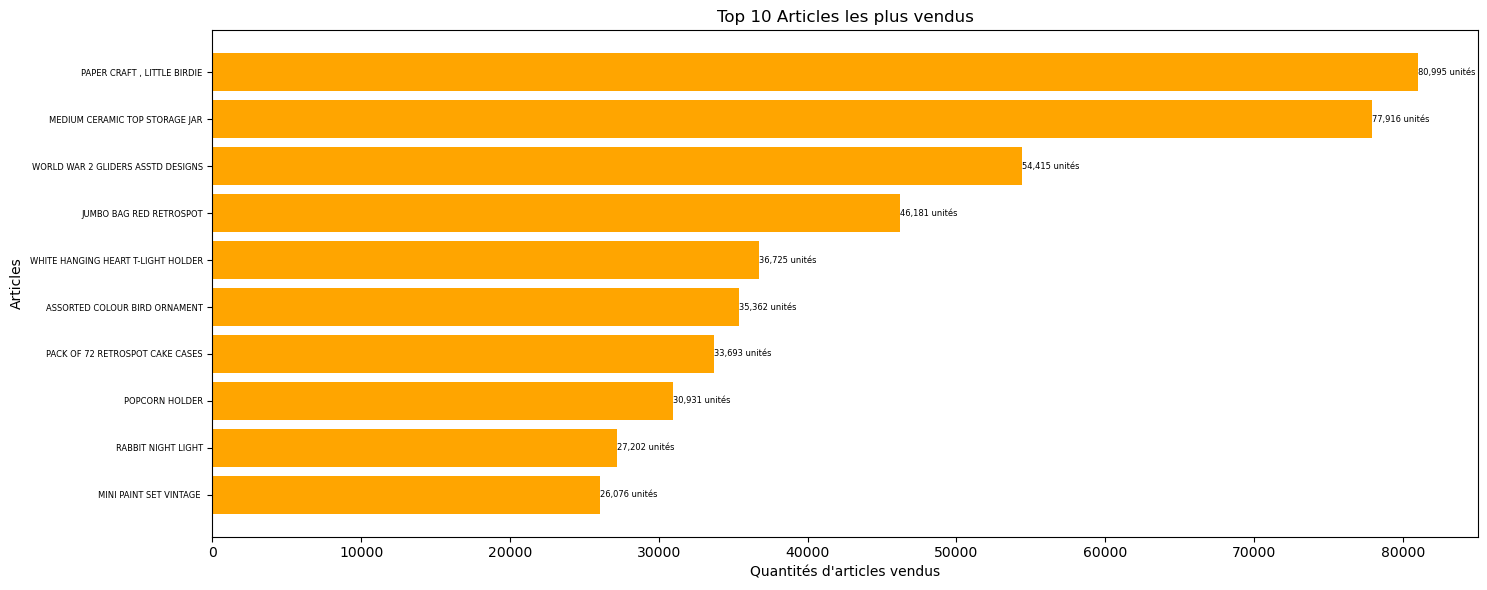

In [82]:
#Graphique top 10 articles
top_10_articles = quantité_par_articles.sort_values(ascending=True).tail(10)
plt.figure(figsize=(15, 6))
plt.barh(top_10_articles.index, top_10_articles.values, color = "orange")
plt.title("Top 10 Articles les plus vendus")
plt.xlabel("Quantités d'articles vendus")
plt.ylabel("Articles")
plt.yticks(fontsize=6)
for articles, valeur in zip(top_10_articles.index, top_10_articles.values):
    plt.text(valeur, articles, f"{valeur:,.0f} unités", ha = "left", va = "center", fontsize = 6)
plt.tight_layout()
plt.show()